In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Set global plotting style
plt.style.use('seaborn-v0_8-whitegrid')
try:
    sns.set_palette('muted')
except:
    pass
sns.set_context('notebook', font_scale=1.1)

In [12]:
DATA_DIR = 'results'

# We will dynamically load all CSV and JSON files in the results directory
data_files = {}
if os.path.exists(DATA_DIR):
    for filename in os.listdir(DATA_DIR):
        filepath = os.path.join(DATA_DIR, filename)
        if filename.endswith('.csv'):
            try:
                data_files[filename] = pd.read_csv(filepath)
                print(f'✅ Successfully loaded: {filename}')
            except Exception as e:
                print(f'❌ Error loading {filename}: {e}')
        elif filename.endswith('.json'):
            try:
                with open(filepath, 'r') as f:
                    data_files[filename] = json.load(f)
                print(f'✅ Successfully loaded: {filename}')
            except Exception as e:
                print(f'❌ Error loading {filename}: {e}')
else:
    print(f'⚠️ Directory {DATA_DIR} not found.')

✅ Successfully loaded: final_demo_results.csv
✅ Successfully loaded: cascade_comparison.csv
✅ Successfully loaded: feature_importance.csv
✅ Successfully loaded: algorithmic_comparison.csv
✅ Successfully loaded: feature_set_experiment_results.csv
✅ Successfully loaded: comprehensive_experiment_results.csv


/var/folders/h0/393fl1hx0_n00kdrbqfdcy1m0000gn/T/ipykernel_15406/261056657.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_data, x='Algorithm', y='Score', palette='Blues_d')


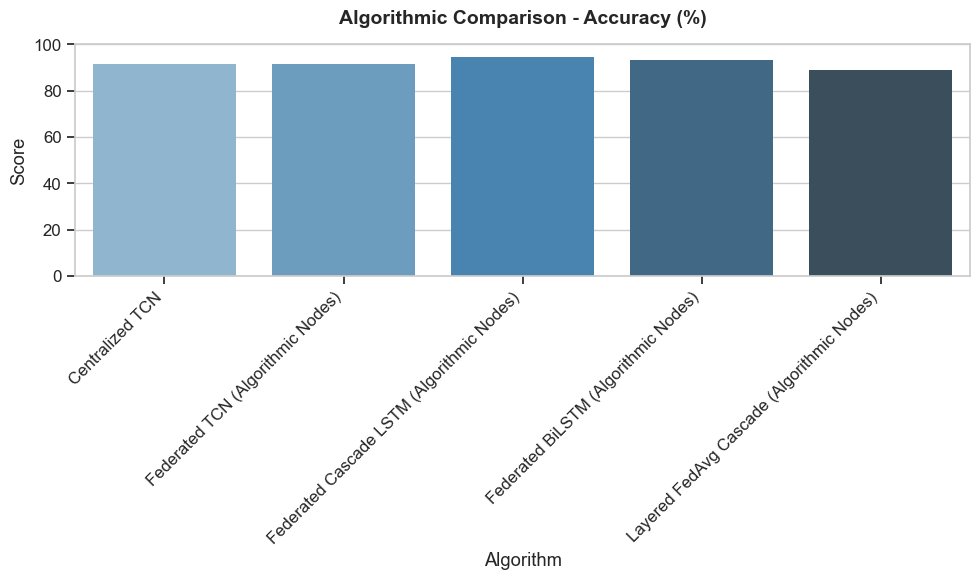

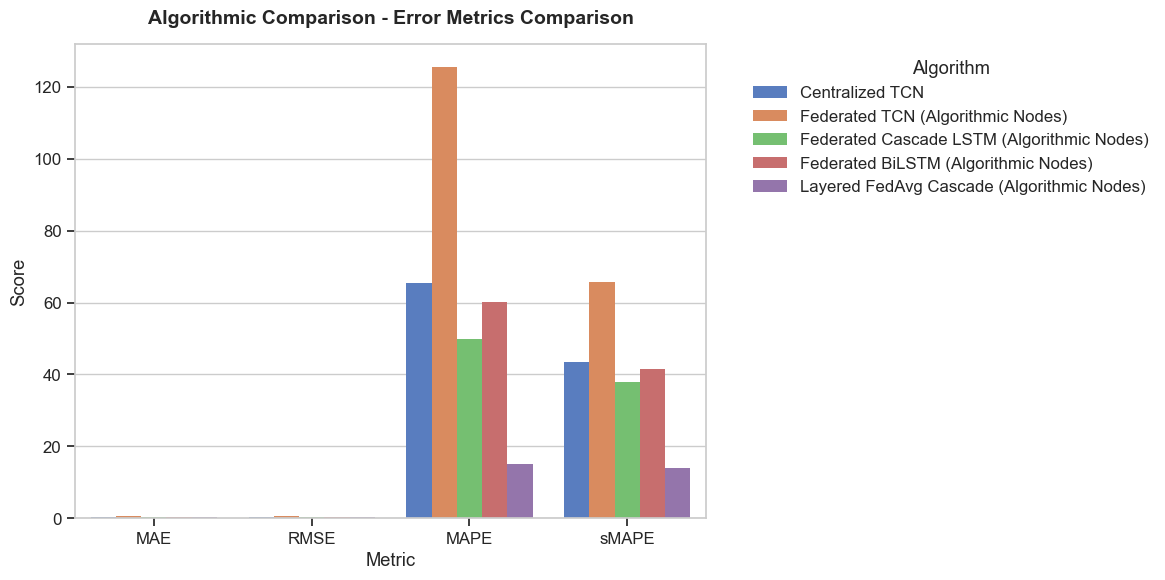

/var/folders/h0/393fl1hx0_n00kdrbqfdcy1m0000gn/T/ipykernel_15406/261056657.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_data, x='Algorithm', y='Score', palette='Blues_d')


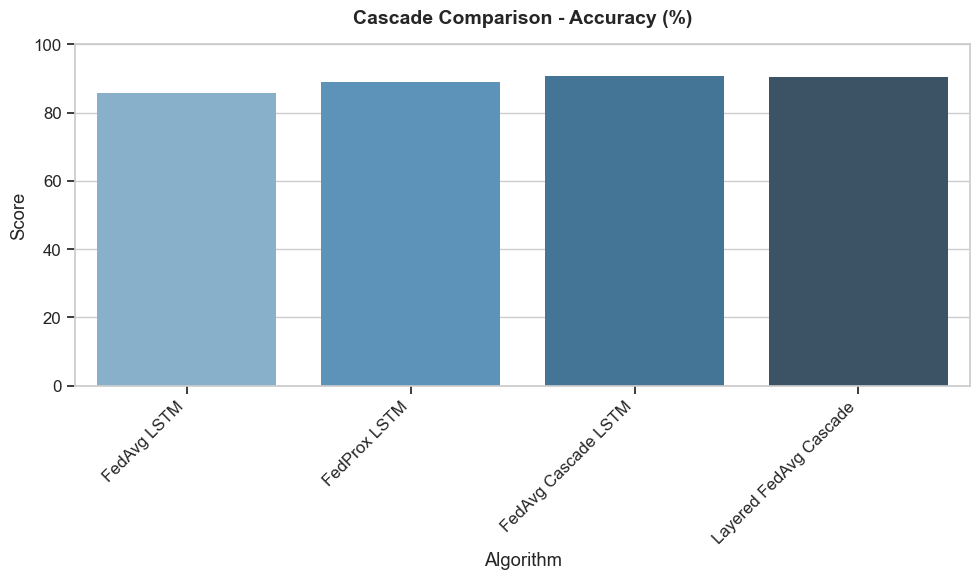

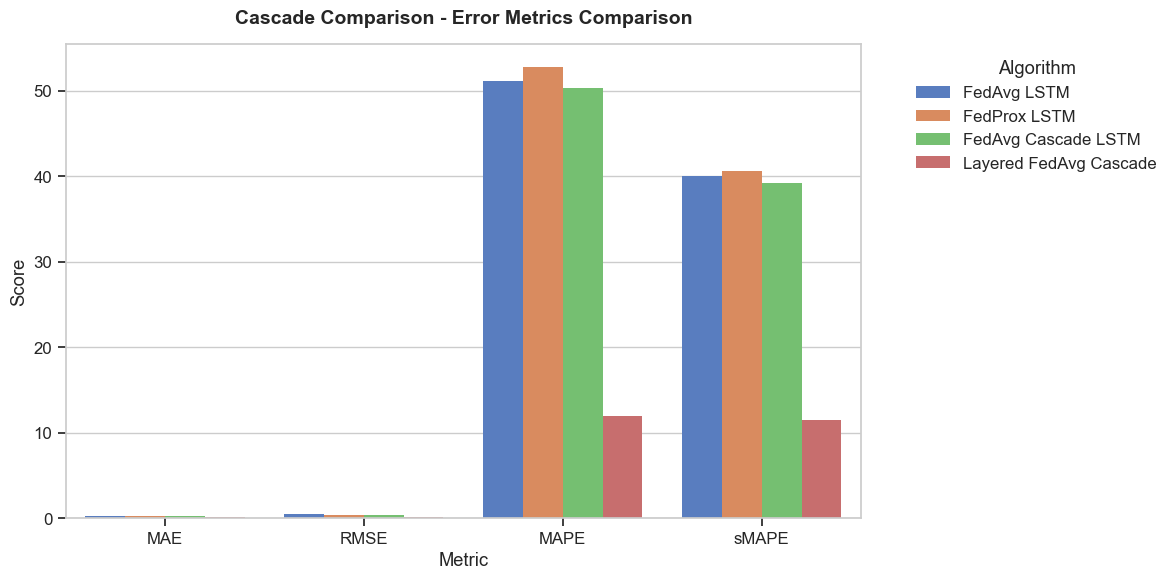

/var/folders/h0/393fl1hx0_n00kdrbqfdcy1m0000gn/T/ipykernel_15406/261056657.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_data, x='Algorithm', y='Score', palette='Blues_d')


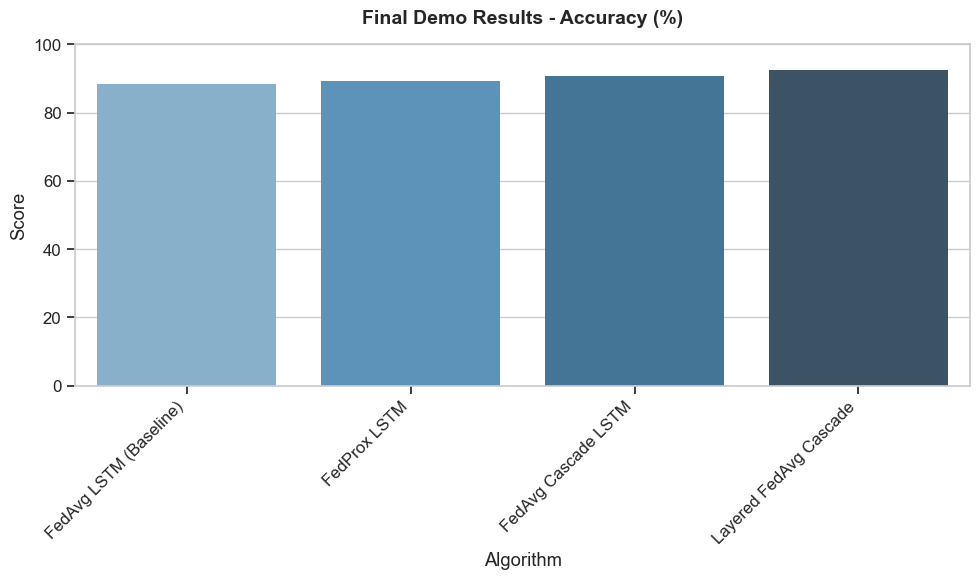

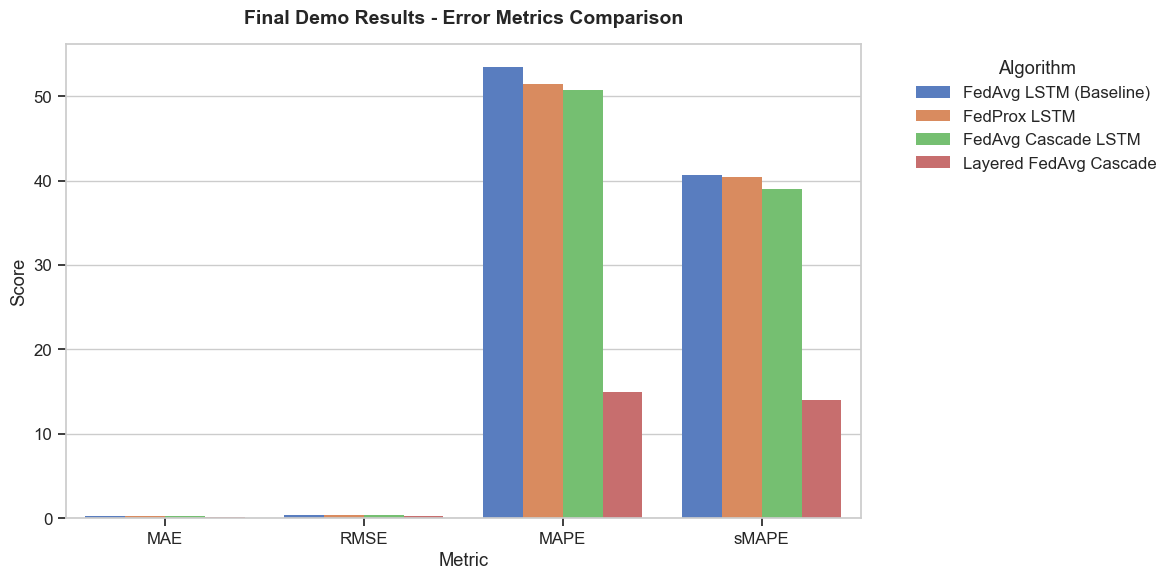

In [13]:
def plot_standard_metrics(df, filename_title):
    """Plots Bar charts for Algorithm comparison across metrics (Accuracy, MAE, RMSE, etc.)"""
    if 'Algorithm' not in df.columns:
        return
        
    df_melt = df.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
    
    # Split Accuracy from error metrics due to scale differences (0-100 vs ~0.1-50)
    acc_data = df_melt[df_melt['Metric'] == 'Accuracy (%)']
    err_data = df_melt[df_melt['Metric'].isin(['MAE', 'RMSE', 'MAPE', 'sMAPE'])]
    
    if not acc_data.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(data=acc_data, x='Algorithm', y='Score', palette='Blues_d')
        plt.title(f'{filename_title} - Accuracy (%)', pad=15, fontsize=14, fontweight='bold')
        plt.ylim(0, 100)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
    if not err_data.empty:
        plt.figure(figsize=(12, 6))
        sns.barplot(data=err_data, x='Metric', y='Score', hue='Algorithm', palette='muted')
        plt.title(f'{filename_title} - Error Metrics Comparison', pad=15, fontsize=14, fontweight='bold')
        plt.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# 1. Iterate explicitly through non-feature-set and non-feature-importance standard comparison results
standard_files = ['algorithmic_comparison.csv', 'cascade_comparison.csv', 'final_demo_results.csv']
for f in standard_files:
    if f in data_files:
        plot_standard_metrics(data_files[f], f.replace('.csv', '').replace('_', ' ').title())

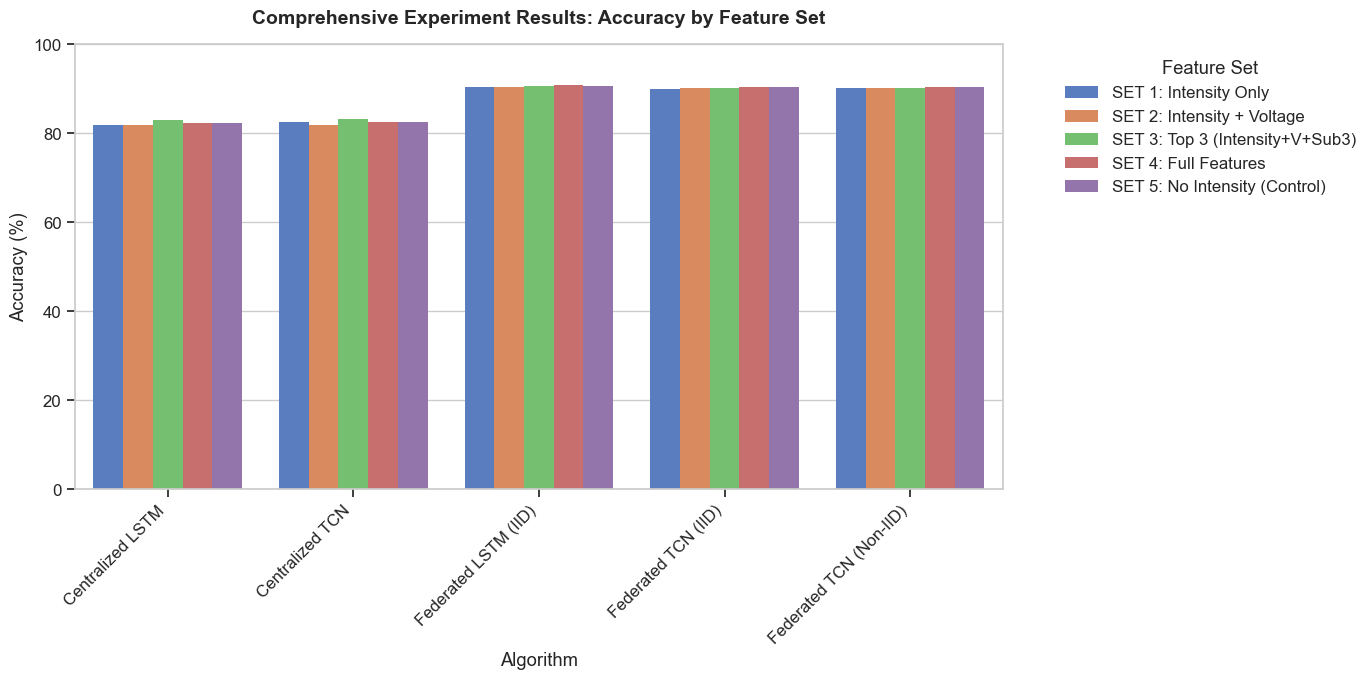

In [14]:
# 2. Visualize Comprehensive Feature Set Experiment Results
feature_set_files = ['comprehensive_experiment_results.csv', 'feature_set_experiment_results.csv']

for f in feature_set_files:
    if f in data_files:
        df = data_files[f]
        if 'Algorithm' in df.columns and 'Feature Set' in df.columns and 'Accuracy (%)' in df.columns:
            plt.figure(figsize=(14, 7))
            sns.barplot(data=df, x='Algorithm', y='Accuracy (%)', hue='Feature Set')
            plt.title(f'{f.replace(".csv","").replace("_"," ").title()}: Accuracy by Feature Set', pad=15, fontsize=14, fontweight='bold')
            plt.ylim(0, 100)
            plt.xticks(rotation=45, ha='right')
            plt.legend(title='Feature Set', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()

In [15]:
# 3. Confusion Matrix Visualization (Graceful skip if unavailable)
cm_file = 'confusion_matrices.json'
if cm_file in data_files:
    cm_data = data_files[cm_file]
    if cm_data:
        num_models = len(cm_data)
        cols = min(3, num_models)
        rows = int(np.ceil(num_models / cols))
        
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
        axes = np.atleast_1d(axes).flatten()
        
        for idx, (model_name, matrix) in enumerate(cm_data.items()):
            ax = axes[idx]
            sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
            ax.set_title(f'{model_name} Confusion Matrix')
            ax.set_xlabel('Predicted Label')
            ax.set_ylabel('True Label')
            
            if np.array(matrix).shape == (2, 2):
                ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
                ax.set_yticklabels(['Negative (0)', 'Positive (1)'])
                
        for idx in range(num_models, len(axes)):
            fig.delaxes(axes[idx])
            
        plt.tight_layout()
        plt.show()
else:
    print('⚠️ cm_data skipped gracefully (Not finding any JSON confusion matrices)')

⚠️ cm_data skipped gracefully (Not finding any JSON confusion matrices)


In [16]:
# 4. Feature Importance Visualization
fi_file = 'feature_importance.csv'
if fi_file in data_files:
    df_fi = data_files[fi_file]
    model_col = 'model' if 'model' in df_fi.columns else 'Algorithm' if 'Algorithm' in df_fi.columns else None
    
    if model_col and 'importance' in df_fi.columns and 'feature' in df_fi.columns:
        models = df_fi[model_col].unique()
        for model in models:
            model_data = df_fi[df_fi[model_col] == model].sort_values(by='importance', ascending=False).head(15)
            
            plt.figure(figsize=(10, 6))
            sns.barplot(data=model_data, x='importance', y='feature', palette='viridis')
            plt.title(f'Top Features: {model}', pad=15, fontsize=14, fontweight='bold')
            plt.xlabel('Importance')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.show()
    else:
        print('feature_importance.csv is present but missing required format/columns.')
else:
    print('⚠️ feature_importance skipped gracefully (Not found)')

feature_importance.csv is present but missing required format/columns.


In [17]:
# Final summary table (Sorted by Accuracy based on active CSVs finding highest accuracy models)
all_summaries = []
for filename, df in data_files.items():
    if filename.endswith('.csv') and 'Algorithm' in df.columns and 'Accuracy (%)' in df.columns:
        # Extract simple max comparisons 
        if 'Feature Set' in df.columns:
            # Group and select top performing feature set for each algorithm
            best_by_algo = df.loc[df.groupby('Algorithm')['Accuracy (%)'].idxmax()]
            best_by_algo = best_by_algo[['Algorithm', 'Accuracy (%)', 'Feature Set']].copy()
            best_by_algo['Source File'] = filename
            all_summaries.append(best_by_algo)
        else:
            temp_df = df[['Algorithm', 'Accuracy (%)']].copy()
            temp_df['Feature Set'] = 'N/A'
            temp_df['Source File'] = filename
            all_summaries.append(temp_df)

if all_summaries:
    final_summary = pd.concat(all_summaries, ignore_index=True)
    final_summary = final_summary.drop_duplicates(subset=['Algorithm', 'Accuracy (%)', 'Source File'])
    final_summary = final_summary.sort_values(by='Accuracy (%)', ascending=False).reset_index(drop=True)
    
    print('=' * 80)
    print('FINAL MODEL COMPARISON (Sorted by Accuracy)')
    print('=' * 80)
    try:
        from IPython.display import display
        display(final_summary)
    except ImportError:
        print(final_summary.to_string())
        
    best_model = final_summary.iloc[0]['Algorithm']
    best_acc = final_summary.iloc[0]['Accuracy (%)']
    best_fs = final_summary.iloc[0]['Feature Set']
    print('\n✨ OVERALL SUMMARY ✨')
    if best_fs == 'N/A':
        print(f'🏆 Best Overall Model: {best_model} (Accuracy: {best_acc:.2f}%)')
    else:
        print(f'🏆 Best Overall Model: {best_model} with {best_fs} (Accuracy: {best_acc:.2f}%)')
else:
    print('No suitable accuracy metrics found across loaded files for final summary.')

FINAL MODEL COMPARISON (Sorted by Accuracy)


,Algorithm,Accuracy (%),Feature Set,Source File
0,Federated Cascade LSTM (Algorithmic Nodes),94.392861,N/A,algorithmic_comparison.csv
1,Federated BiLSTM (Algorithmic Nodes),93.302009,N/A,algorithmic_comparison.csv
2,Layered FedAvg Cascade,92.432777,N/A,final_demo_results.csv
3,Federated TCN (Algorithmic Nodes),91.745474,N/A,algorithmic_comparison.csv
4,Centralized TCN,91.507947,N/A,algorithmic_comparison.csv
5,FedAvg Cascade LSTM,90.870590,N/A,final_demo_results.csv
6,Federated LSTM (IID),90.805349,SET 4: Full Features,comprehensive_experiment_results.csv
7,FedAvg Cascade LSTM,90.706442,N/A,cascade_comparison.csv
8,Federated TCN (IID),90.498096,SET 5: No Intensity (Control),comprehensive_experiment_results.csv
9,Layered FedAvg Cascade,90.409838,N/A,cascade_comparison.csv



✨ OVERALL SUMMARY ✨
🏆 Best Overall Model: Federated Cascade LSTM (Algorithmic Nodes) (Accuracy: 94.39%)
